# Visualizacion de datos (Punto 6)

Se consolidan los 7 graficos que representan los hallazgos mas importantes del analisis, reutilizando las funciones ya validadas de los puntos 2 (distribucion de ventas), 4 (segmentacion de clientes) y 5 (correlacion).

## Criterio de seleccion

Se eligieron 7 graficos que cubren distintos tipos (linea, barras, dispersion y mapa de calor) y distintas etapas del analisis, priorizando los hallazgos con mayor valor de negocio: estacionalidad de ventas, canal de venta preferido, segmentacion por edad y genero, impacto de boletines/vales, y las dos correlaciones mas relevantes (venta vs edad, genero vs metodo de pago).

## Preparacion del entorno

En Google Colab, agregue `DB_HOST`, `DB_PORT`, `DB_NAME`, `DB_USER` y `DB_PASSWORD` en el panel **Secrets** y habilite su acceso. La siguiente celda instala las dependencias, clona el repositorio y crea un archivo `.env` temporal sin mostrar las credenciales. En Jupyter local se utiliza el repositorio y el `.env` existentes.

In [1]:
import os
import subprocess
import sys
from pathlib import Path

EN_COLAB = 'google.colab' in sys.modules
REPOSITORIO = 'https://github.com/AngelMendoz/SOG2-2S26_grupo8.git'

if EN_COLAB:
    subprocess.run(
        [sys.executable, '-m', 'pip', 'install', '-q',
         'numpy>=1.26', 'pandas>=2.2', 'psycopg2-binary>=2.9',
         'python-dotenv>=1.0', 'SQLAlchemy>=2.0', 'seaborn>=0.13',
         'matplotlib>=3.8', 'scipy>=1.11'],
        check=True,
    )
    raiz_repositorio = Path('/content/SOG2-2S26_grupo8')
    if not raiz_repositorio.is_dir():
        subprocess.run(['git', 'clone', '--depth', '1', REPOSITORIO, str(raiz_repositorio)], check=True)
    RAIZ_PRACTICA = raiz_repositorio / 'Practica_1'

    from google.colab import userdata

    nombres_secretos = ('DB_HOST', 'DB_PORT', 'DB_NAME', 'DB_USER', 'DB_PASSWORD')
    secretos = {}
    for nombre in nombres_secretos:
        try:
            valor = userdata.get(nombre)
        except Exception as error:
            raise ValueError(f'Falta habilitar el secreto {nombre} en Google Colab.') from error
        if not valor:
            raise ValueError(f'El secreto {nombre} esta vacio en Google Colab.')
        secretos[nombre] = valor
    (RAIZ_PRACTICA / '.env').write_text(
        ''.join(f'{nombre}={valor}\n' for nombre, valor in secretos.items()),
        encoding='utf-8',
    )
else:
    RAIZ_PRACTICA = Path.cwd().resolve()
    if not (RAIZ_PRACTICA / 'app').is_dir():
        RAIZ_PRACTICA = RAIZ_PRACTICA.parent

if not (RAIZ_PRACTICA / 'app').is_dir():
    raise FileNotFoundError('No se encontro la carpeta Practica_1.')

if str(RAIZ_PRACTICA) not in sys.path:
    sys.path.insert(0, str(RAIZ_PRACTICA))

print(f'Entorno listo: {RAIZ_PRACTICA}')

Entorno listo: C:\Users\jmcr3\Desktop\SOG2-2S26_grupo8\Practica_1


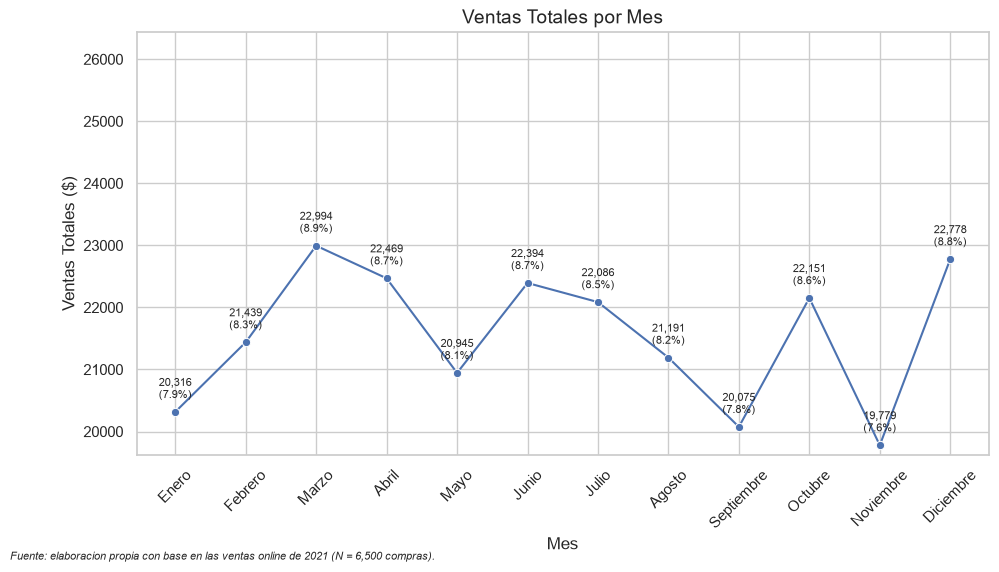

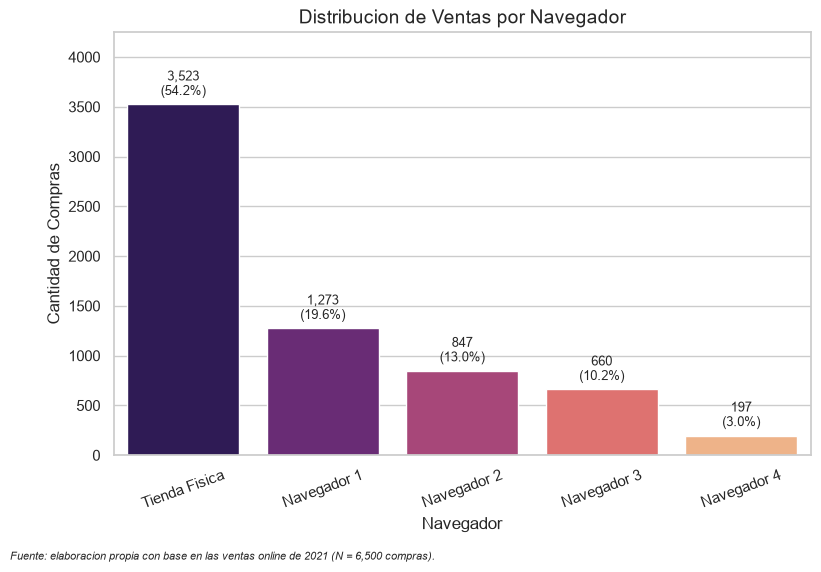

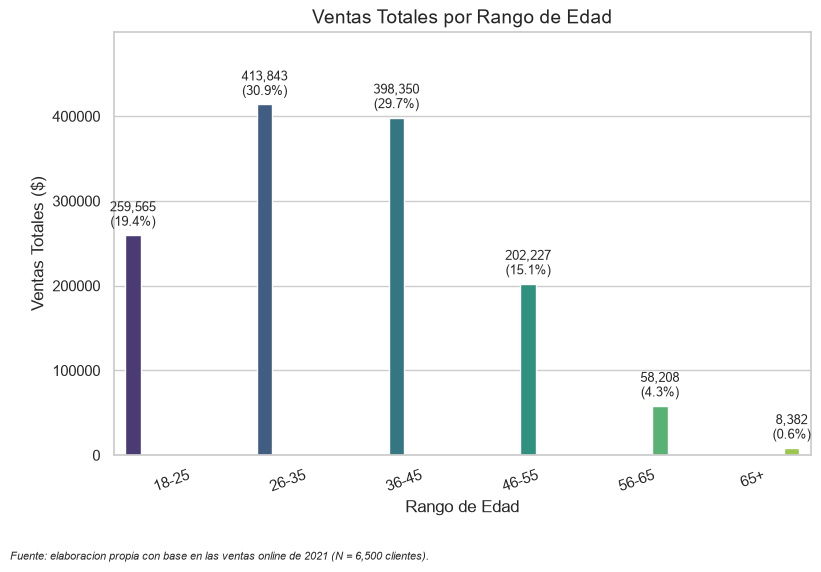

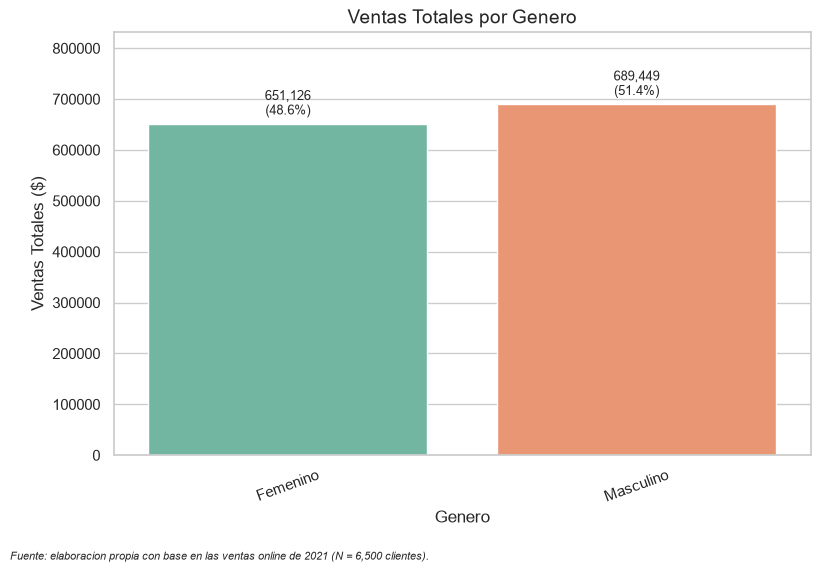

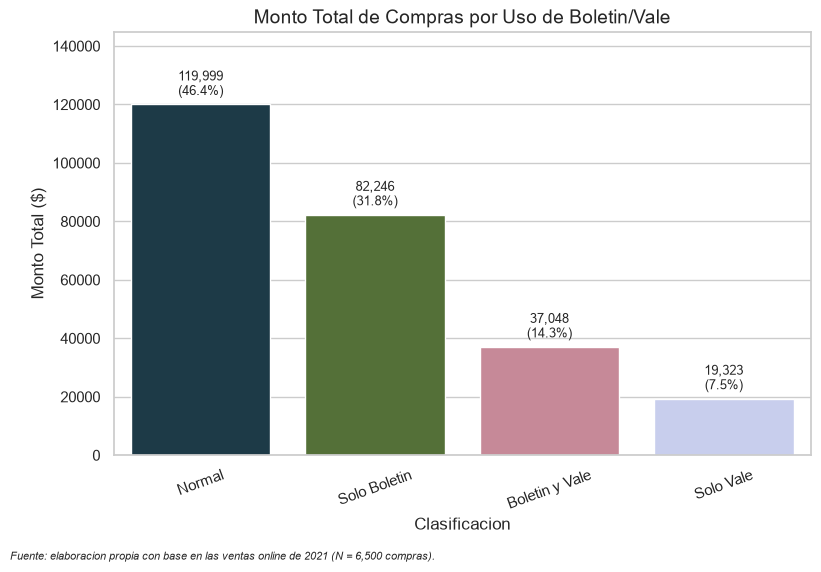

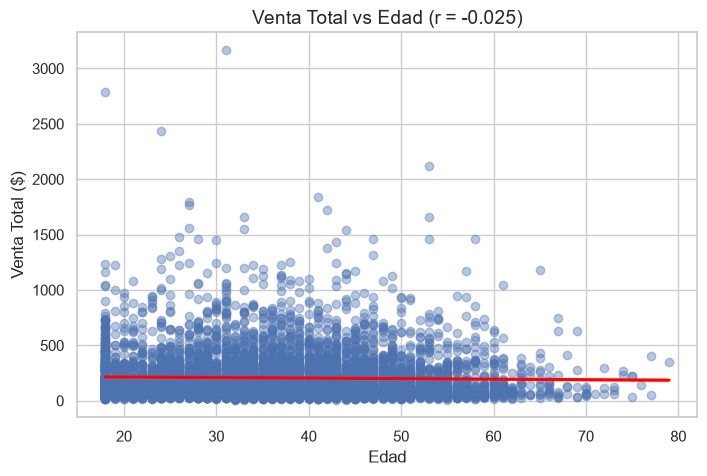

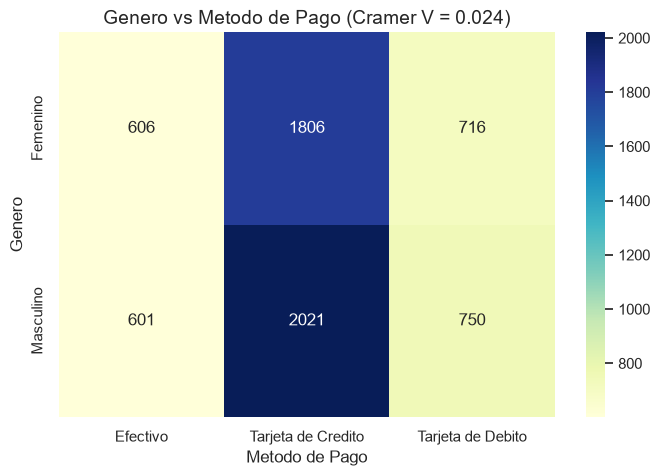

7 hallazgos generados en C:\Users\jmcr3\Desktop\SOG2-2S26_grupo8\Practica_1\06-Visualizacion-datos\resultados


In [2]:
from IPython.display import Image, display

from app.analisis.punto_02 import crear_motor, obtener_datos
from app.analisis.punto_06 import HALLAZGOS, ejecutar_visualizacion_hallazgos

directorio_resultados = RAIZ_PRACTICA / '06-Visualizacion-datos' / 'resultados'

motor = crear_motor()
clientes, compras, _control = obtener_datos(motor)

ejecutar_visualizacion_hallazgos(clientes, compras, directorio_resultados=directorio_resultados)
print(f'{len(HALLAZGOS)} hallazgos generados en {directorio_resultados}')

## 1. Ventas totales por mes (linea)

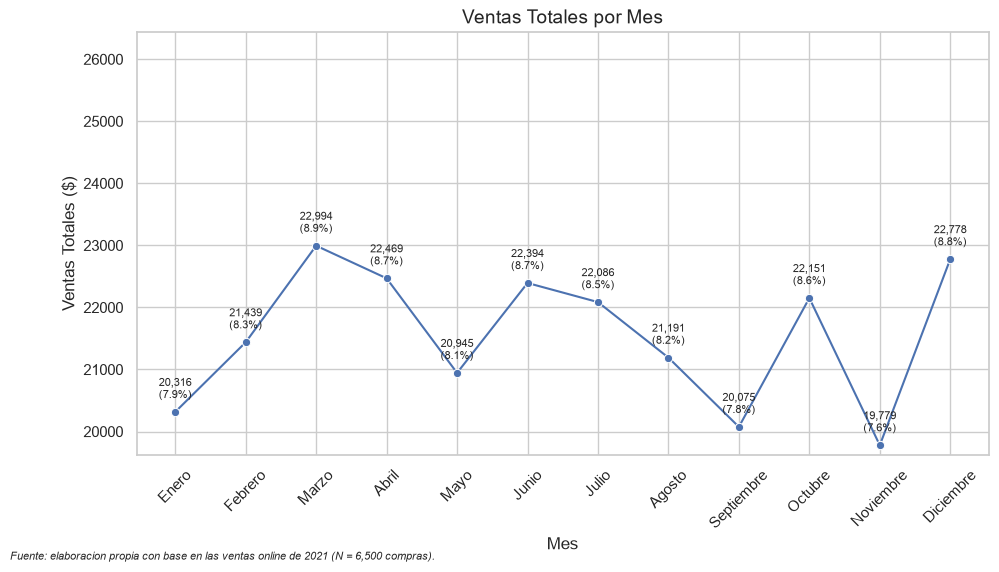

In [3]:
display(Image(filename=str(directorio_resultados / HALLAZGOS['ventas_por_mes']['archivo'])))

## 2. Navegador mas y menos usado (barras)

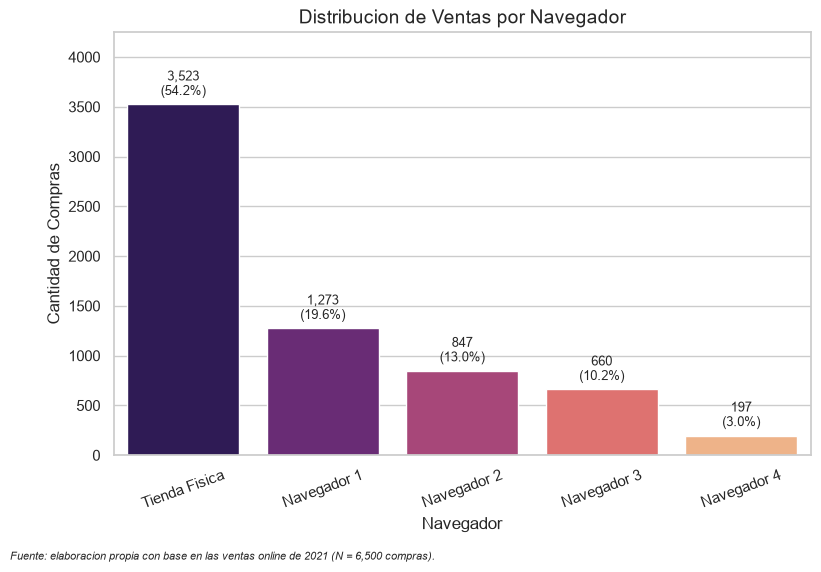

In [4]:
display(Image(filename=str(directorio_resultados / HALLAZGOS['navegador_mas_usado']['archivo'])))

## 3. Ventas totales por rango de edad (barras)

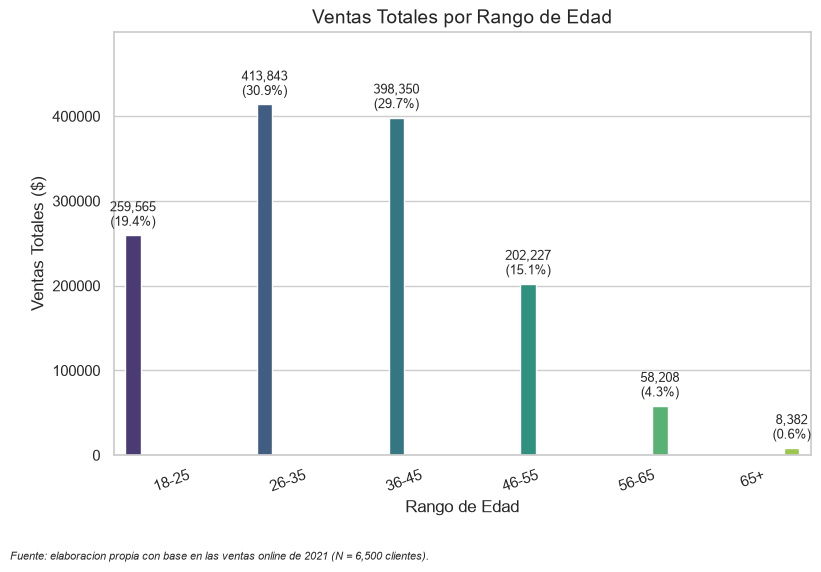

In [5]:
display(Image(filename=str(directorio_resultados / HALLAZGOS['ventas_por_edad']['archivo'])))

## 4. Ventas totales por genero (barras)

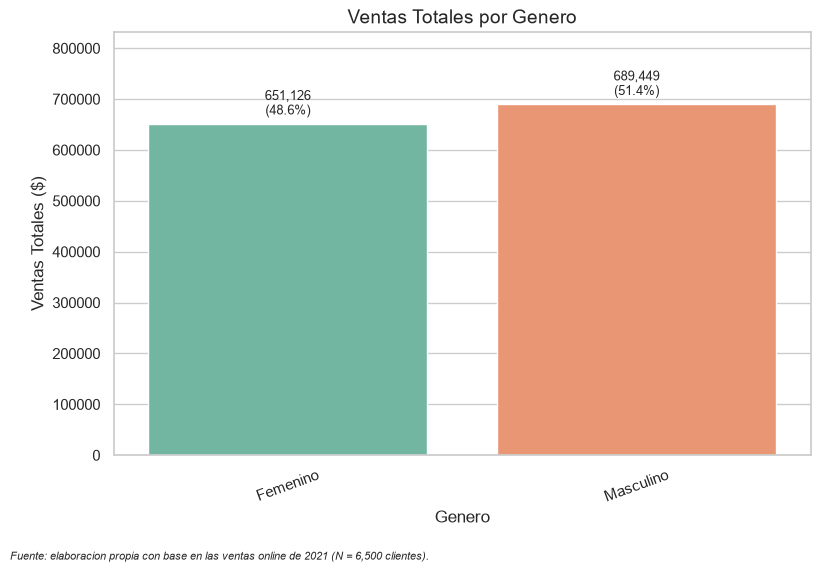

In [6]:
display(Image(filename=str(directorio_resultados / HALLAZGOS['ventas_por_genero']['archivo'])))

## 5. Monto total por uso de boletin y vale (barras)

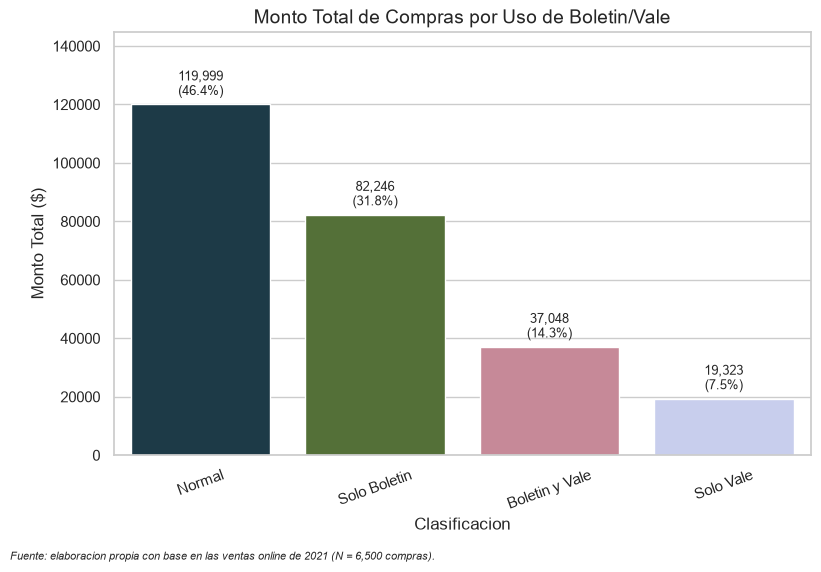

In [7]:
display(Image(filename=str(directorio_resultados / HALLAZGOS['boletin_vale']['archivo'])))

## 6. Correlacion entre venta total y edad (dispersion)

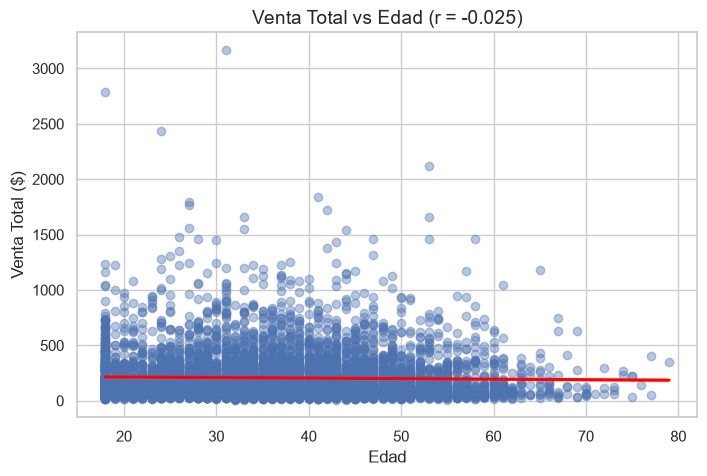

In [8]:
display(Image(filename=str(directorio_resultados / HALLAZGOS['venta_vs_edad']['archivo'])))

## 7. Correlacion entre genero y metodo de pago (mapa de calor)

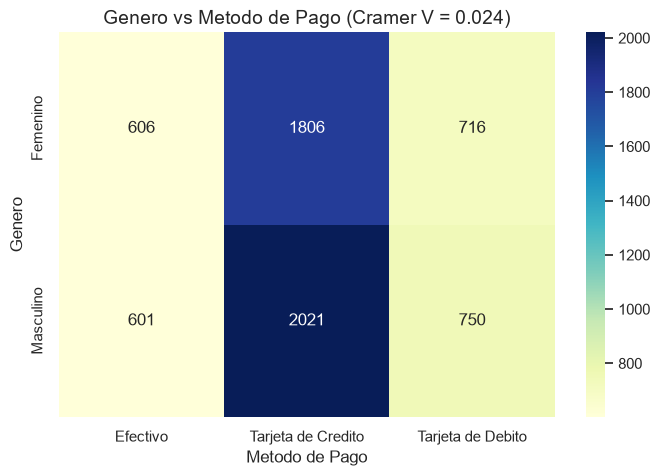

In [9]:
display(Image(filename=str(directorio_resultados / HALLAZGOS['genero_vs_metodo_pago']['archivo'])))